In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg, hour,date_trunc, count, unix_timestamp, col, corr
import matplotlib.pyplot as plt
import requests
import pandas as pd

In [2]:
START_DATE = "2026-01-01"
END_DATE = "2026-05-31"

In [3]:
# 1. 데이터 프레임 로드
spark = SparkSession.builder \
    .appName("TLC_Ingestion") \
    .master("spark://spark-master:7077") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

df = spark.read.parquet("/opt/spark-data/yellow_tripdata_2026-*.parquet")
df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [4]:
# 2. 결측치 확인
from pyspark.sql.functions import col, sum as spark_sum, when

df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
]).show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       0|                   0|                    0|        4812280|            0|   4812280|           4812280|           0|    

In [5]:
# 3. 시간 필드 표준화 + 탑승 시간 컬럼 구하기
df_clean = df.withColumn(
    "trip_duration_min",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60
)

In [6]:
# 4. 말도 안되는 값 필터링
df_clean = df_clean.filter(
    (col("trip_distance") > 0) &
    (col("trip_distance") < 100) &          # 비현실적으로 긴 거리 컷
    (col("trip_duration_min") > 0) &
    (col("trip_duration_min") < 240) &      # 4시간 넘는 트립은 이상치로 간주
    (col("passenger_count") > 0) &
    (col("fare_amount") > 0)
)

In [7]:
# 5. null처리

# 핵심 분석에 필요한 컬럼(시간, 거리)에 null 있으면 그 행은 버림
df_clean = df_clean.dropna(subset=["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance"])

# passenger_count처럼 없어도 분석 가능한 컬럼은 기본값으로 대체
df_clean = df_clean.fillna({"passenger_count": 1})

In [8]:
# 6. 원본 및 필터 후 비교
print("원본 row 수:", df.count())
print("정제 후 row 수:", df_clean.count())

원본 row 수: 18999282
정제 후 row 수: 13607566


In [9]:
# 7. Df 캐싱
df_clean.cache()
df_clean.count()  # 캐시를 강제로 실체화(action 한번 호출)

13607566

In [10]:
# 8. 지표 구하기 및 정규화

# 평균 지표
metrics = df_clean.agg(
    avg("trip_duration_min").alias("avg_duration_min"),
    avg("trip_distance").alias("avg_distance_miles")
)
metrics.show()

# 시간대 추출
df_clean = df_clean.withColumn("pickup_hour", hour("tpep_pickup_datetime"))

+------------------+------------------+
|  avg_duration_min|avg_distance_miles|
+------------------+------------------+
|17.723646212702945|3.4375381952947723|
+------------------+------------------+



In [11]:
# 9. 시간대별 트립 건수 집계

hourly_counts = df_clean.groupBy("pickup_hour") \
    .agg(count("*").alias("trip_count")) \
    .orderBy("pickup_hour")

hourly_counts.show(24)

+-----------+----------+
|pickup_hour|trip_count|
+-----------+----------+
|          0|    328142|
|          1|    210357|
|          2|    134590|
|          3|     92305|
|          4|     66115|
|          5|     86605|
|          6|    184372|
|          7|    364613|
|          8|    509331|
|          9|    591802|
|         10|    644170|
|         11|    697766|
|         12|    751741|
|         13|    779360|
|         14|    843234|
|         15|    884779|
|         16|    899705|
|         17|    967126|
|         18|    978859|
|         19|    851072|
|         20|    780053|
|         21|    792575|
|         22|    680307|
|         23|    488587|
+-----------+----------+



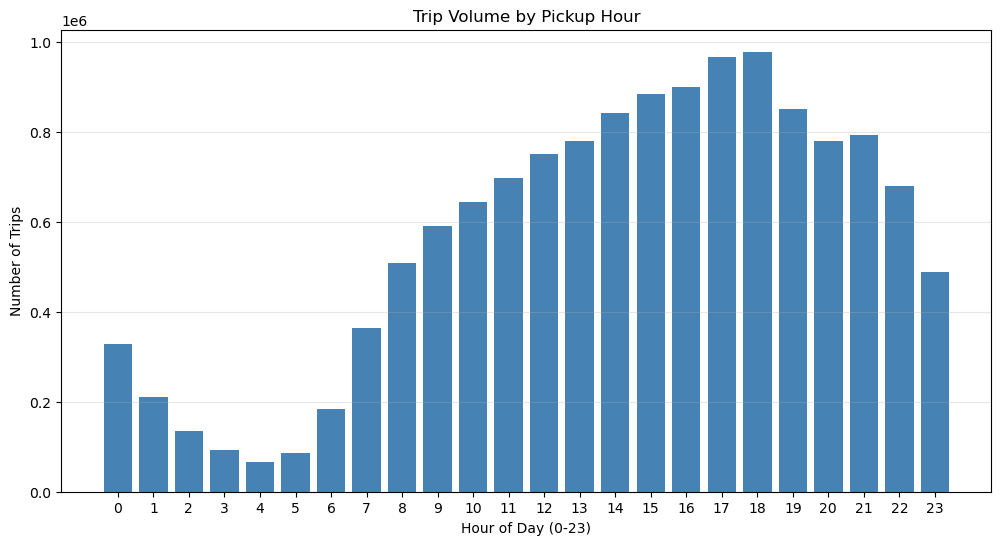

In [12]:
# 10. 시간대별 분포 시각화
hourly_pd = hourly_counts.toPandas()
hourly_pd

plt.figure(figsize=(12, 6))
plt.bar(hourly_pd["pickup_hour"], hourly_pd["trip_count"], color="steelblue")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Number of Trips")
plt.title("Trip Volume by Pickup Hour")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)
plt.show()

In [13]:
# 11. 피크 시간 표기
mean_count = hourly_pd["trip_count"].mean()
std_count = hourly_pd["trip_count"].std()
threshold = mean_count + 0.9 * std_count  # 평균 + 0.9 * 표준편차 이상을 피크로 정의

hourly_pd["is_peak"] = hourly_pd["trip_count"] > threshold
print(hourly_pd[hourly_pd["is_peak"]])

    pickup_hour  trip_count  is_peak
15           15      884779     True
16           16      899705     True
17           17      967126     True
18           18      978859     True
19           19      851072     True


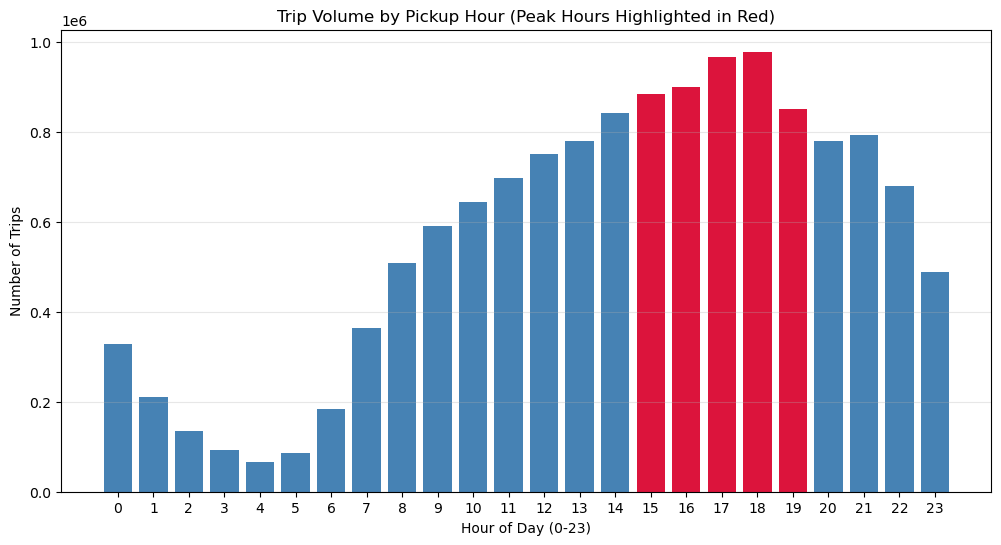

In [14]:
# 12. 피크 시간이 표기된 그래프

colors = ["crimson" if h else "steelblue" for h in hourly_pd["is_peak"]]

plt.figure(figsize=(12, 6))
plt.bar(hourly_pd["pickup_hour"], hourly_pd["trip_count"], color=colors)
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Number of Trips")
plt.title("Trip Volume by Pickup Hour (Peak Hours Highlighted in Red)")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)
plt.show()

In [15]:
# 13. 외부 날씨 소스 가져오기
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 40.7128,
    "longitude": -74.0060,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": "temperature_2m,precipitation,snowfall,windspeed_10m",
    "timezone": "America/New_York"
}
resp = requests.get(url, params=params)
weather_json = resp.json()

weather_pd = pd.DataFrame(weather_json["hourly"])
weather_pd["time"] = pd.to_datetime(weather_pd["time"])
weather_pd.head()

,time,temperature_2m,precipitation,snowfall,windspeed_10m
0,2026-01-01 00:00:00,-1.0,0.0,0.00,13.0
1,2026-01-01 01:00:00,-0.8,0.1,0.07,13.0
2,2026-01-01 02:00:00,-0.4,0.1,0.07,13.3
3,2026-01-01 03:00:00,-0.2,0.0,0.00,13.4
4,2026-01-01 04:00:00,0.4,0.0,0.00,14.0


In [16]:
weather_sdf = spark.createDataFrame(weather_pd)
weather_sdf = weather_sdf.withColumnRenamed("time", "weather_hour")
weather_sdf.show(5)

+-------------------+--------------+-------------+--------+-------------+
|       weather_hour|temperature_2m|precipitation|snowfall|windspeed_10m|
+-------------------+--------------+-------------+--------+-------------+
|2026-01-01 00:00:00|          -1.0|          0.0|     0.0|         13.0|
|2026-01-01 01:00:00|          -0.8|          0.1|    0.07|         13.0|
|2026-01-01 02:00:00|          -0.4|          0.1|    0.07|         13.3|
|2026-01-01 03:00:00|          -0.2|          0.0|     0.0|         13.4|
|2026-01-01 04:00:00|           0.4|          0.0|     0.0|         14.0|
+-------------------+--------------+-------------+--------+-------------+
only showing top 5 rows



In [17]:
# 14. 택시 데이터 hour 처리
df_hourly = df_clean.withColumn("pickup_hour_ts", date_trunc("hour", "tpep_pickup_datetime"))

trip_counts_by_hour = df_hourly.groupBy("pickup_hour_ts") \
    .agg(count("*").alias("trip_count"))

trip_counts_by_hour.show(5)

+-------------------+----------+
|     pickup_hour_ts|trip_count|
+-------------------+----------+
|2026-03-01 02:00:00|      2717|
|2026-03-01 05:00:00|       522|
|2026-03-01 10:00:00|      3400|
|2026-03-02 13:00:00|      4930|
|2026-03-02 17:00:00|      6492|
+-------------------+----------+
only showing top 5 rows



In [18]:
# 15. 날씨 및 테시 데이터 inner join
joined = trip_counts_by_hour.join(
    weather_sdf,
    trip_counts_by_hour.pickup_hour_ts == weather_sdf.weather_hour,
    "inner"
)
joined.show(5)

+-------------------+----------+-------------------+--------------+-------------+--------+-------------+
|     pickup_hour_ts|trip_count|       weather_hour|temperature_2m|precipitation|snowfall|windspeed_10m|
+-------------------+----------+-------------------+--------------+-------------+--------+-------------+
|2026-03-01 02:00:00|      2717|2026-03-01 02:00:00|          -2.0|          0.0|     0.0|          5.0|
|2026-03-01 05:00:00|       522|2026-03-01 05:00:00|          -1.4|          0.0|     0.0|         11.7|
|2026-03-01 10:00:00|      3400|2026-03-01 10:00:00|           0.4|          0.2|    0.14|         14.2|
|2026-03-02 13:00:00|      4930|2026-03-02 13:00:00|          -3.5|          0.0|     0.0|          5.0|
|2026-03-02 17:00:00|      6492|2026-03-02 17:00:00|          -2.3|          0.0|     0.0|          5.4|
+-------------------+----------+-------------------+--------------+-------------+--------+-------------+
only showing top 5 rows



In [19]:
# 16. 날씨 - 택시 상관관계
joined.select(
    corr("trip_count", "temperature_2m").alias("corr_temp"),
    corr("trip_count", "precipitation").alias("corr_precip"),
    corr("trip_count", "snowfall").alias("corr_snow"),
    corr("trip_count", "windspeed_10m").alias("corr_wind")
).show()

+-------------------+-------------------+--------------------+-------------------+
|          corr_temp|        corr_precip|           corr_snow|          corr_wind|
+-------------------+-------------------+--------------------+-------------------+
|0.28687065870431105|-0.0505995624136332|-0.12715402877314133|0.10148374231461711|
+-------------------+-------------------+--------------------+-------------------+



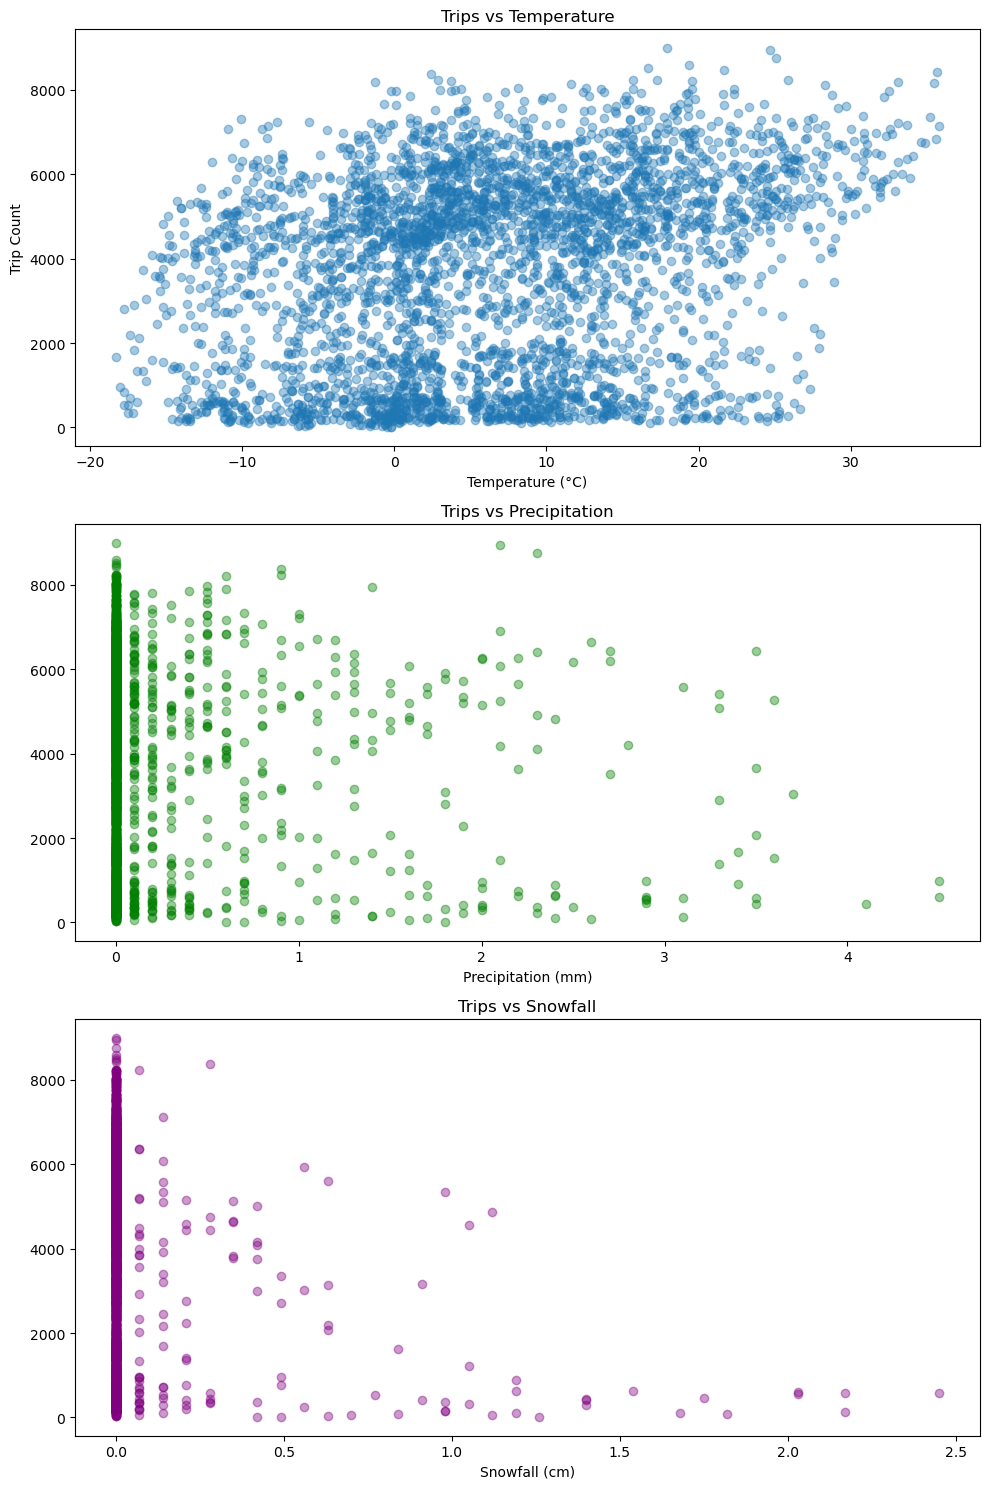

In [20]:
# 17. 최종 시각화 산점도

joined_pd = joined.select("trip_count", "temperature_2m", "precipitation", "snowfall").toPandas()

fig, axes = plt.subplots(3, 1, figsize=(10,15))

axes[0].scatter(joined_pd["temperature_2m"], joined_pd["trip_count"], alpha=0.4)
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Trip Count")
axes[0].set_title("Trips vs Temperature")

axes[1].scatter(joined_pd["precipitation"], joined_pd["trip_count"], alpha=0.4, color="green")
axes[1].set_xlabel("Precipitation (mm)")
axes[1].set_title("Trips vs Precipitation")

axes[2].scatter(joined_pd["snowfall"], joined_pd["trip_count"], alpha=0.4, color="purple")
axes[2].set_xlabel("Snowfall (cm)")
axes[2].set_title("Trips vs Snowfall")

plt.tight_layout()
plt.show()

In [29]:
# 18. output 저장
metrics.write.mode("overwrite").csv("/opt/spark-output/metrics", header=True)
hourly_counts.write.mode("overwrite").csv("/opt/spark-output/hourly_counts", header=True)
joined.write.mode("overwrite").parquet("/opt/spark-output/weather_trip_joined")

Py4JJavaError: An error occurred while calling o333.csv.
: java.util.NoSuchElementException: None.get
	at scala.None$.get(Option.scala:529)
	at scala.None$.get(Option.scala:527)
	at org.apache.spark.sql.execution.datasources.BasicWriteJobStatsTracker$.metrics(BasicWriteStatsTracker.scala:239)
	at org.apache.spark.sql.execution.command.DataWritingCommand.metrics(DataWritingCommand.scala:55)
	at org.apache.spark.sql.execution.command.DataWritingCommand.metrics$(DataWritingCommand.scala:55)
	at org.apache.spark.sql.execution.datasources.InsertIntoHadoopFsRelationCommand.metrics$lzycompute(InsertIntoHadoopFsRelationCommand.scala:47)
	at org.apache.spark.sql.execution.datasources.InsertIntoHadoopFsRelationCommand.metrics(InsertIntoHadoopFsRelationCommand.scala:47)
	at org.apache.spark.sql.execution.command.DataWritingCommandExec.metrics$lzycompute(commands.scala:109)
	at org.apache.spark.sql.execution.command.DataWritingCommandExec.metrics(commands.scala:109)
	at org.apache.spark.sql.execut